# Tahap 1 : Melakukan Import Library Yang Dibutuhkan

In [ ]:
!pip install emoji
!pip install gensim
!pip install sastrawi
!pip install gdown
!pip install contractions
!pip install transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.1 MB/s eta 0:00:00


In [ ]:
!pip install transformers

In [ ]:
import datetime as dt
import re
import string
import csv
import json
import warnings
import requests
from io import StringIO
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
pd.options.mode.chained_assignment = None
np.random.seed(0)

import gdown
import emoji
import contractions
import transformer
from gensim.models import FastText
from transformers import pipeline
from transformers import RobertaTokenizer

import matplotlib.pyplot as plt
import seaborn as sns

from nltk.stem import PorterStemmer
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical

from wordcloud import WordCloud

# install (jalankan sekali saja)
!pip install emoji
!pip install sastrawi
!pip install gdown
!pip install contractions

# download nltk resource
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Tahap 2 : Melakukan Load Dataset

In [ ]:
# Melakukan pengunduhan dataset
file_id = "1Beu5Y8A7PKkxTAPaNmugs01wCEBeky8o"
output = "scrapping_pubg.csv"
gdown.download(f"https://drive.google.com/uc?id={file_id}", output, quiet=False)

# Melakukan load dataset
df = pd.read_csv('scrapping_pubg.csv')
df.head()

Downloading...
From: https://drive.google.com/uc?id=1Beu5Y8A7PKkxTAPaNmugs01wCEBeky8o
To: /content/scrapping_pubg.csv
100%|██████████| 1.58M/1.58M [00:00<00:00, 170MB/s]


,reviewId,content,score
0,06686361-ea85-43b8-b83e-33c388b3eae9,bug,5
1,f5dc7048-1007-4bd6-937a-6534e51a858d,my dad in his ipad is playing with his friends...,5
2,c9a1e68e-632d-4e24-b7b7-28a6b5993f84,good game,5
3,8d3faaf4-0ff0-42f2-9388-13082f652c1a,one of the best mobile game ever played in my ...,5
4,54d27e67-f260-422d-8f4e-9b14d1221938,My favourite mobile game just so much updates ...,4


In [ ]:
# Melakukan pengunduhan slangwords
file_id_slang = "1osUBUyiHD_l-wVI9X0KO5ZQDLyvfoA9Y"
output_slang = "slangwords.json"
gdown.download(f"https://drive.google.com/uc?id={file_id_slang}", output_slang)

# Melakukan load slangwords
with open('slangwords.json', 'r', encoding='UTF-8') as file:
    slangwords = json.load(file)

print("\n", list(slangwords.items()))


Downloading...
From: https://drive.google.com/uc?id=1osUBUyiHD_l-wVI9X0KO5ZQDLyvfoA9Y
To: /content/slangwords.json
100%|██████████| 7.15k/7.15k [00:00<00:00, 13.5MB/s]


 [('$', ' dollar '), ('€', ' euro '), ('4ao', 'for adults only'), ('a.m', 'before midday'), ('a3', 'anytime anywhere anyplace'), ('aamof', 'as a matter of fact'), ('acct', 'account'), ('adih', 'another day in hell'), ('afaic', 'as far as i am concerned'), ('afaict', 'as far as i can tell'), ('afaik', 'as far as i know'), ('afair', 'as far as i remember'), ('afk', 'away from keyboard'), ('app', 'application'), ('approx', 'approximately'), ('apps', 'applications'), ('asap', 'as soon as possible'), ('asl', 'age, sex, location'), ('atk', 'at the keyboard'), ('ave.', 'avenue'), ('aymm', 'are you my mother'), ('ayor', 'at your own risk'), ('b&b', 'bed and breakfast'), ('b+b', 'bed and breakfast'), ('b.c', 'before christ'), ('b2b', 'business to business'), ('b2c', 'business to customer'), ('b4', 'before'), ('b4n', 'bye for now'), ('b@u', 'back at you'), ('bae', 'before anyone else'), ('bak', 'back at keyboard'), ('bbbg', 'bye bye be good'), ('bbc', 'british broadcasting corporation'), ('bbia

# Tahap 3 : Melakukan Data Understanding

In [ ]:
# Memahami karakteristik umum dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   reviewId  15000 non-null  object
 1   content   15000 non-null  object
 2   score     15000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 351.7+ KB


In [ ]:
# Melakukan pengecekan terhadap nilai NaN
df.isna().sum()

,0
reviewId,0
content,0
score,0


In [ ]:
# Melakukan pengecekan terhadap nilai dupplicate
df.duplicated().sum()

np.int64(0)

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

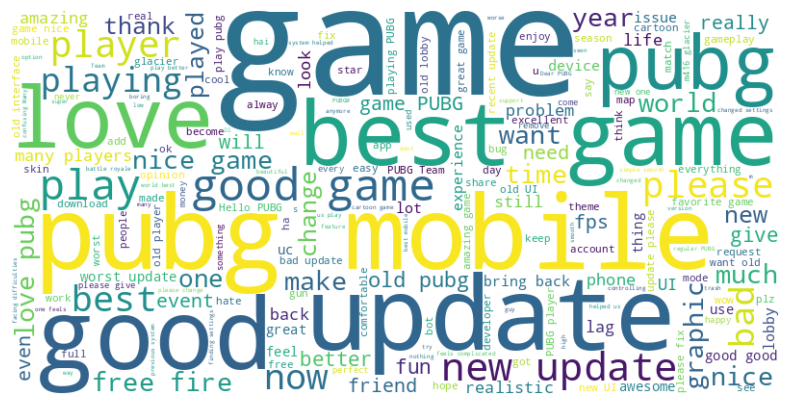

In [ ]:
# Melakukan visualisasi wordcloud awal
text = " ".join(df['content'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis('off')

Text(0, 0.5, 'Frekuensi')

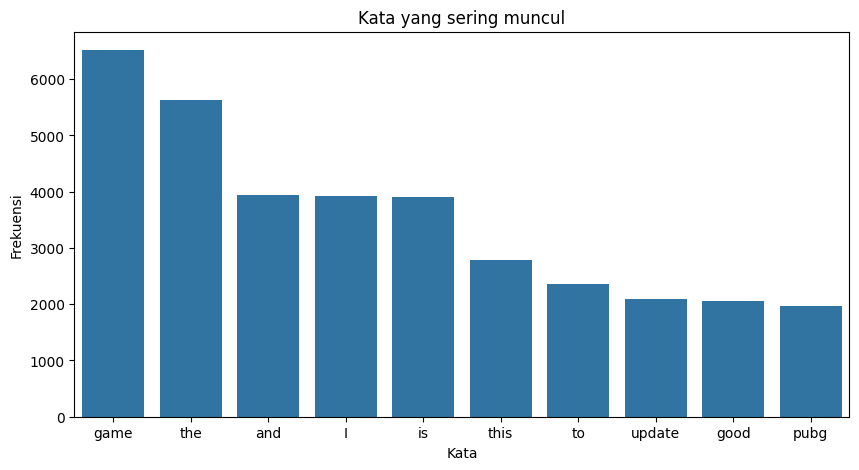

In [ ]:
# Melihat kata kata yang sering muncul
count_words = pd.Series(text.split()).value_counts()[:10]
plt.figure(figsize = (10,5))
sns.barplot(x = count_words.index, y = count_words.values)
plt.title('Kata yang sering muncul')
plt.xlabel('Kata')
plt.ylabel('Frekuensi')

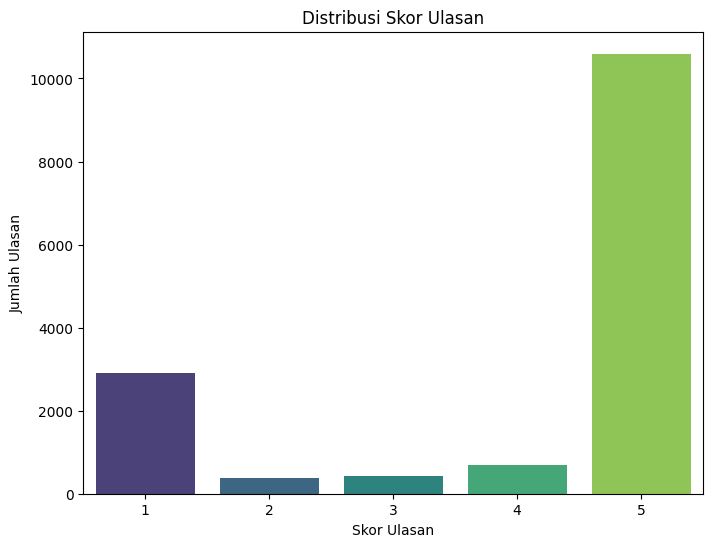

In [ ]:
# Melakukan visualisasi jumlah ulasan per score
plt.figure(figsize=(8, 6))
sns.countplot(x='score', data=df, palette='viridis')
plt.title('Distribusi Skor Ulasan')
plt.xlabel('Skor Ulasan')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [ ]:
# Melihat kata kata yang sering muncul pada rating 5, 3 dan 1
# Mengambil konten dengan rating 1
df_rate_1 = df[df['score'] == 1]['content']

# Mengambil konten dengan rating 3
df_rate_3 = df[df['score'] == 3]['content'] # Dilambangkan sebagai netral

# Mengambil konten dengan rating 5
df_rate_5 = df[df['score'] == 5]['content']

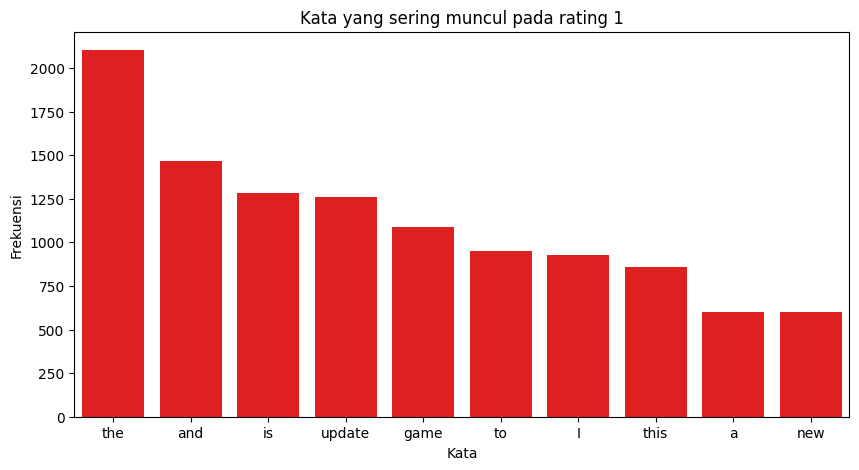

In [ ]:
# Menghitung jumlah kata per rating
count_words_rate_1 = pd.Series(" ".join(df_rate_1.astype(str)).split()).value_counts()
count_words_rate_3 = pd.Series(" ".join(df_rate_3.astype(str)).split()).value_counts()
count_words_rate_5 = pd.Series(" ".join(df_rate_5.astype(str)).split()).value_counts()

# Membuat fungsi barplot
def bar_plot(count_words, title, color):
    most = count_words[:10]
    plt.figure(figsize=(10, 5))
    sns.barplot(x=most.index, y=most.values, color=color)
    plt.title(title)
    plt.xlabel('Kata')
    plt.ylabel('Frekuensi')
    plt.show()

# Panggil fungsi tersebut
bar_plot(count_words_rate_1, 'Kata yang sering muncul pada rating 1', 'red')

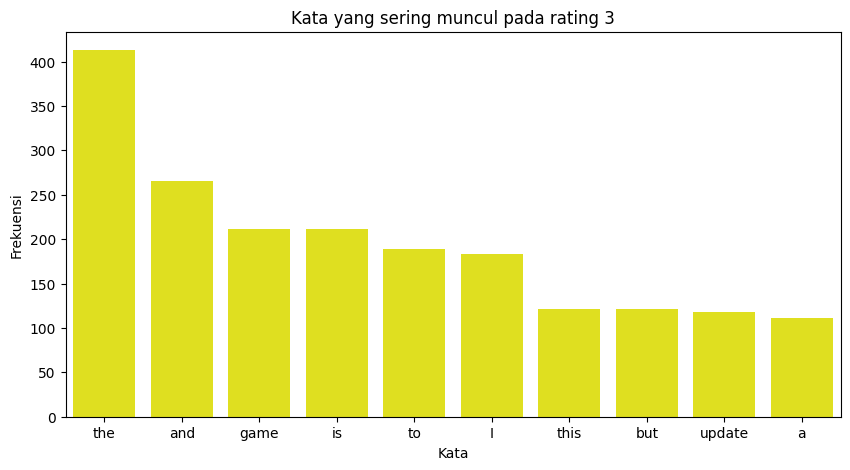

In [ ]:
# Panggil fungsi tersebut
bar_plot(count_words_rate_3, 'Kata yang sering muncul pada rating 3', 'yellow')

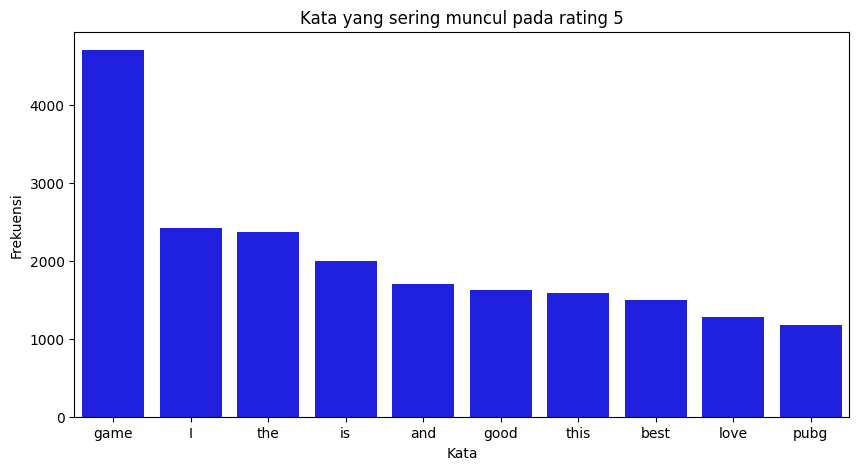

In [ ]:
# Panggil fungsi tersebut
bar_plot(count_words_rate_5, 'Kata yang sering muncul pada rating 5', 'blue')

# Tahap 4 : Data Preparation

## 4.1 Membuat Fungsi Preprocessing Data

In [ ]:
# Fungsi preprocessing awal
def clean_text(text):
    # Mengubah seluruh teks menjadi huruf kecil
    text = text.lower()

    # Menghapus karakter baris baru (newline)
    text = text.replace('\n', ' ')

    # Menghapus URL dan username
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)

    # Mengambil kata dari hashtag tanpa simbol '#'
    text = re.sub(r'#(\w+)', r'\1', text)

    # Mengonversi emoji menjadi representasi teks
    text = emoji.demojize(text)
    text = text.replace(":", " ")

    # Mengubah kata kontraksi menjadi bentuk lengkap
    text = contractions.fix(text)

    # Menghapus karakter selain huruf
    text = re.sub(r'[^a-z\s]', ' ', text)

    # Menormalisasi karakter yang berulang
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Menghapus spasi berlebih
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Membuat fungsi tokenisasi
def tokenize(text):
    return word_tokenize(text)

# Membuat fungsi menghapus stopwords
def remove_stopwords(text):
    stop_words = set(stopwords.words('english'))
    filtered_text = [word for word in text if word not in stop_words]
    return filtered_text

# Membuat fungsi tokenisasi untuk roberta
tokenizer_roberta = RobertaTokenizer.from_pretrained('roberta-base')
def roberta_tokenize(text):
    return tokenizer_roberta.tokenize(text)

# Melakukan stemming
ps = PorterStemmer()
def stemming(text):
    text = [ps.stem(word) for word in text]
    return ' '.join(text)

# Fungsi menghilangkan stopwords
def fixed_slangwords(text):
    words = text.split()
    fix_slangwords = [slangwords.get(word.lower(), word) for word in words]
    return ' '.join(fix_slangwords)


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## 4.2 Data Preparation Untuk Model LSTM dan ML Traditional

In [ ]:
# Melakukan copy dataset untuk preprocessing
clean_df = df.copy()

# Membersihkan teks kemudian menyimpannya dalam kolom text_clean
clean_df['text_clean'] = clean_df['content'].apply(clean_text)

# Mengganti slangwords dengan kata kata yang lebih baku dan menyimpannya di dalam text_slangwords
clean_df['text_slangwords'] = clean_df['text_clean'].apply(fixed_slangwords)

# Melakukan tokenisasi terhadap teks dan menyimpannya pada kolom text_tokenizingText
clean_df['text_tokenizingText'] = clean_df['text_slangwords'].apply(tokenize)

# Melakukan penghapusan stopwords dan menyimpannya pada kolom text_stopwords
clean_df['text_stopwords'] = clean_df['text_tokenizingText'].apply(remove_stopwords)

# Melakukan stemming terhadap teks dan menyimpannya pada kolom text_stemming
clean_df['text_akhir'] = clean_df['text_stopwords'].apply(stemming)

In [ ]:
# Memeriksa hasil setelah preprocessing
clean_df.head()

,reviewId,content,score,text_clean,text_slangwords,text_tokenizingText,text_stopwords,text_akhir
0,06686361-ea85-43b8-b83e-33c388b3eae9,bug,5,bug,bug,[bug],[bug],bug
1,f5dc7048-1007-4bd6-937a-6534e51a858d,my dad in his ipad is playing with his friends...,5,my dad in his ipad is playing with his friends...,my dad in his ipad is playing with his friends...,"[my, dad, in, his, ipad, is, playing, with, hi...","[dad, ipad, playing, friends, going, install, ...",dad ipad play friend go instal play dad
2,c9a1e68e-632d-4e24-b7b7-28a6b5993f84,good game,5,good game,good game,"[good, game]","[good, game]",good game
3,8d3faaf4-0ff0-42f2-9388-13082f652c1a,one of the best mobile game ever played in my ...,5,one of the best mobile game ever played in my ...,one of the best mobile game ever played in my ...,"[one, of, the, best, mobile, game, ever, playe...","[one, best, mobile, game, ever, played, life]",one best mobil game ever play life
4,54d27e67-f260-422d-8f4e-9b14d1221938,My favourite mobile game just so much updates ...,4,my favourite mobile game just so much updates ...,my favourite mobile game just so much updates ...,"[my, favourite, mobile, game, just, so, much, ...","[favourite, mobile, game, much, updates, enoug...",favourit mobil game much updat enough space pl...


# Tahap 5 : Pelabelan

In [ ]:
# Melakukan labelling dengan menggunakan roberta
classifier = pipeline("sentiment-analysis", model="cardiffnlp/twitter-roberta-base-sentiment")

def get_roberta_label(text):
    result = classifier(text, truncation = True, max_length=512)[0]
    return result['label']


config.json:   0%|          | 0.00/747 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

In [ ]:
clean_df['label_roberta'] = clean_df['text_akhir'].apply(get_roberta_label)

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [ ]:
# Melakukan mapping ulang terhadap hasil labelling
label_map = {
    'LABEL_0': 'negative',
    'LABEL_1': 'neutral',
    'LABEL_2': 'positive'
}

# Terapkan ke kolom label hasil RoBERTa tadi
clean_df['label_roberta'] = clean_df['label_roberta'].map(label_map)

# Tahap 6 : Melihat Distribusi Label

In [ ]:
# Melihat 100 data awal pada label negative
clean_df[clean_df['label_roberta'] == "negative"].head(100)

,reviewId,content,score,text_clean,text_slangwords,text_tokenizingText,text_stopwords,text_akhir,text_akhir_bert,label_roberta
21,098a6376-f002-4765-be5f-70876ad86bc5,full of addiction,1,full of addiction,full of addiction,"[full, of, addiction]","[full, addiction]",full addict,"[full, Ġof, Ġaddiction]",negative
33,68e9a3d8-7387-49cc-ad53-a2b5ac1debc7,shity sound muzzles that have been added made ...,1,shity sound muzzles that have been added made ...,shity sound muzzles that have been added made ...,"[shity, sound, muzzles, that, have, been, adde...","[shity, sound, muzzles, added, made, sucks]",shiti sound muzzl ad made suck,"[sh, ity, Ġsound, Ġm, uzz, les, Ġthat, Ġhave, ...",negative
40,5a621b94-e872-4838-9380-05785b8630ce,I hate this game,1,i hate this game,i hate this game,"[i, hate, this, game]","[hate, game]",hate game,"[i, Ġhate, Ġthis, Ġgame]",negative
105,cb16adda-6ade-4113-b5bd-fe588064be5a,current season update is so worst.,1,current season update is so worst,current season update is so worst,"[current, season, update, is, so, worst]","[current, season, update, worst]",current season updat worst,"[current, Ġseason, Ġupdate, Ġis, Ġso, Ġworst]",negative
125,bf36520b-e267-413c-8c10-72f769797c3f,having internet problem,5,having internet problem,having internet problem,"[having, internet, problem]","[internet, problem]",internet problem,"[having, Ġinternet, Ġproblem]",negative
...,...,...,...,...,...,...,...,...,...,...
1392,fe00a917-f86e-4228-b604-4fe73d62086e,always my bad luck 😔,1,always my bad luck pensive face,always my bad luck pensive face,"[always, my, bad, luck, pensive, face]","[always, bad, luck, pensive, face]",alway bad luck pensiv face,"[always, Ġmy, Ġbad, Ġluck, Ġp, ensive, Ġface]",negative
1425,c7775f03-88ab-4c65-a245-6bf6512969e2,I downgraded rating - please please remove pig...,1,i downgraded rating please please remove pig c...,i downgraded rating please please remove pig c...,"[i, downgraded, rating, please, please, remove...","[downgraded, rating, please, please, remove, p...",downgrad rate pleas pleas remov pig chicken bu...,"[i, Ġdown, graded, Ġrating, Ġplease, Ġplease, ...",negative
1455,8d9fddf9-6bac-443e-9ea4-9ba939e19953,Hello PUBG mobile You are fake game you not gi...,1,hello pubg mobile you are fake game you not gi...,hello pubg mobile you are fake game you not gi...,"[hello, pubg, mobile, you, are, fake, game, yo...","[hello, pubg, mobile, fake, game, give, uc, gl...",hello pubg mobil fake game give uc glacier fac...,"[hello, Ġpub, g, Ġmobile, Ġyou, Ġare, Ġfake, Ġ...",negative
1535,5c6dee0d-8165-462f-8a48-f821ffe8ee23,This time the song is boring. I disliked it.,3,this time the song is boring i disliked it,this time the song is boring i disliked it,"[this, time, the, song, is, boring, i, dislike...","[time, song, boring, disliked]",time song bore dislik,"[this, Ġtime, Ġthe, Ġsong, Ġis, Ġboring, Ġi, Ġ...",negative


In [ ]:
# Melihat 100 data awal pada label positive
clean_df[clean_df['label_roberta'] == "positive"].head(100)

,reviewId,content,score,text_clean,text_slangwords,text_tokenizingText,text_stopwords,text_akhir,text_akhir_bert,label_roberta
2,c9a1e68e-632d-4e24-b7b7-28a6b5993f84,good game,5,good game,good game,"[good, game]","[good, game]",good game,"[good, Ġgame]",positive
3,8d3faaf4-0ff0-42f2-9388-13082f652c1a,one of the best mobile game ever played in my ...,5,one of the best mobile game ever played in my ...,one of the best mobile game ever played in my ...,"[one, of, the, best, mobile, game, ever, playe...","[one, best, mobile, game, ever, played, life]",one best mobil game ever play life,"[one, Ġof, Ġthe, Ġbest, Ġmobile, Ġgame, Ġever,...",positive
4,54d27e67-f260-422d-8f4e-9b14d1221938,My favourite mobile game just so much updates ...,4,my favourite mobile game just so much updates ...,my favourite mobile game just so much updates ...,"[my, favourite, mobile, game, just, so, much, ...","[favourite, mobile, game, much, updates, enoug...",favourit mobil game much updat enough space pl...,"[my, Ġfavourite, Ġmobile, Ġgame, Ġjust, Ġso, Ġ...",positive
6,aa2f9909-ca28-4c67-997a-67161bec4d00,pubg is the best game I love pubg🧠,5,pubg is the best game i love pubg brain,pubg is the best game i love pubg brain,"[pubg, is, the, best, game, i, love, pubg, brain]","[pubg, best, game, love, pubg, brain]",pubg best game love pubg brain,"[pub, g, Ġis, Ġthe, Ġbest, Ġgame, Ġi, Ġlove, Ġ...",positive
7,5be31ef1-7e87-4a60-8090-58e7ad57b8e7,Best Game in The World But We want the old UI ...,5,best game in the world but we want the old ui ...,best game in the world but we want the old ui ...,"[best, game, in, the, world, but, we, want, th...","[best, game, world, want, old, ui, please, pub...",best game world want old ui pleas pubg fold ha...,"[best, Ġgame, Ġin, Ġthe, Ġworld, Ġbut, Ġwe, Ġw...",positive
...,...,...,...,...,...,...,...,...,...,...
202,4df982d8-0cb3-4dcb-a9b7-d3f603b43169,the game is good for me,5,the game is good for me,the game is good for me,"[the, game, is, good, for, me]","[game, good]",game good,"[the, Ġgame, Ġis, Ġgood, Ġfor, Ġme]",positive
203,a2fb9e38-29fa-45be-a2ad-eb5d0689a4d5,nice game,4,nice game,nice game,"[nice, game]","[nice, game]",nice game,"[nice, Ġgame]",positive
206,835b74f8-7b3e-4ec7-853b-beb9ad41bda5,this good!👌❤️🔥✨,5,this good hand red heart fire sparkles,this good hand red heart fire sparkles,"[this, good, hand, red, heart, fire, sparkles]","[good, hand, red, heart, fire, sparkles]",good hand red heart fire sparkl,"[this, Ġgood, Ġhand, Ġred, Ġheart, Ġfire, Ġspa...",positive
207,d0916fa6-52f4-4232-8a34-284e28b75766,This game is good.but the starting time is ver...,4,this game is good but the starting time is ver...,this game is good but the starting time is ver...,"[this, game, is, good, but, the, starting, tim...","[game, good, starting, time, long, foreihate, ...",game good start time long foreih game thumb,"[this, Ġgame, Ġis, Ġgood, Ġbut, Ġthe, Ġstartin...",positive


In [ ]:
# Melihat 100 data awal pada label neutral
clean_df[clean_df['label_roberta'] == "neutral"].head(100)

,reviewId,content,score,text_clean,text_slangwords,text_tokenizingText,text_stopwords,text_akhir,text_akhir_bert,label_roberta
0,06686361-ea85-43b8-b83e-33c388b3eae9,bug,5,bug,bug,[bug],[bug],bug,[bug],neutral
1,f5dc7048-1007-4bd6-937a-6534e51a858d,my dad in his ipad is playing with his friends...,5,my dad in his ipad is playing with his friends...,my dad in his ipad is playing with his friends...,"[my, dad, in, his, ipad, is, playing, with, hi...","[dad, ipad, playing, friends, going, install, ...",dad ipad play friend go instal play dad,"[my, Ġdad, Ġin, Ġhis, Ġip, ad, Ġis, Ġplaying, ...",neutral
5,a39a0838-1583-4d19-a9e0-1fb03340db8c,best,5,best,best,[best],[best],best,[best],neutral
10,18202f34-7b92-4d36-adc2-4e3d836dabb2,no spech will needed,5,no spech will needed,no spech will needed,"[no, spech, will, needed]","[spech, needed]",spech need,"[no, Ġspe, ch, Ġwill, Ġneeded]",neutral
12,84f486ee-9edc-4e26-b2d9-d772896b8798,1. Collection Showroom: can't visit other play...,1,collection showroom cannot visit other players...,collection showroom cannot visit other players...,"[collection, showroom, can, not, visit, other,...","[collection, showroom, visit, players, houses,...",collect showroom visit player hous hous parti ...,"[collection, Ġshow, room, Ġcannot, Ġvisit, Ġot...",neutral
...,...,...,...,...,...,...,...,...,...,...
204,af340882-4c67-4ea6-9be0-8aa61602d3b9,game laggs to much play battle Royale instead,1,game laggs to much play battle royale instead,game laggs to much play battle royale instead,"[game, laggs, to, much, play, battle, royale, ...","[game, laggs, much, play, battle, royale, inst...",game lagg much play battl royal instead,"[game, Ġl, agg, s, Ġto, Ġmuch, Ġplay, Ġbattle,...",neutral
205,47ef05b0-4fd1-4491-a8c0-640b867675f7,❤️‍🩹,5,mending heart,mending heart,"[mending, heart]","[mending, heart]",mend heart,"[m, ending, Ġheart]",neutral
208,80a7fed1-4438-4dbd-b745-ba03ae01686d,من افضل الالعاب اللي لعبتها بس عشان التحديث بق...,4,,,[],[],,[],neutral
210,02e5ce7a-5cb7-4f60-9a71-6fc460fed3fa,world number 1 game pubg mobile 📱 👌 😎,5,world number game pubg mobile mobile phone han...,world number game pubg mobile mobile phone han...,"[world, number, game, pubg, mobile, mobile, ph...","[world, number, game, pubg, mobile, mobile, ph...",world number game pubg mobil mobil phone hand ...,"[world, Ġnumber, Ġgame, Ġpub, g, Ġmobile, Ġmob...",neutral


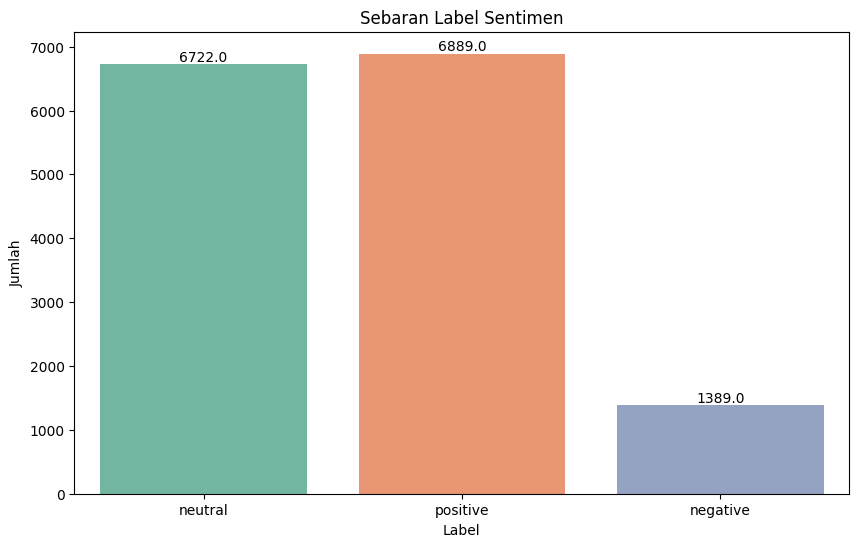

In [ ]:
# Melihat visualisasi sebaran data
plt.figure(figsize=(10,6))
ax = sns.countplot(x='label_roberta', data=clean_df, palette='Set2')

# Tambahkan angka di atas bar sesuai urutan plot
for p in ax.patches:
    ax.annotate(str(p.get_height()),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Sebaran Label Sentimen')
plt.xlabel('Label')
plt.ylabel('Jumlah')
plt.show()

## 1. Sentimen Positif

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

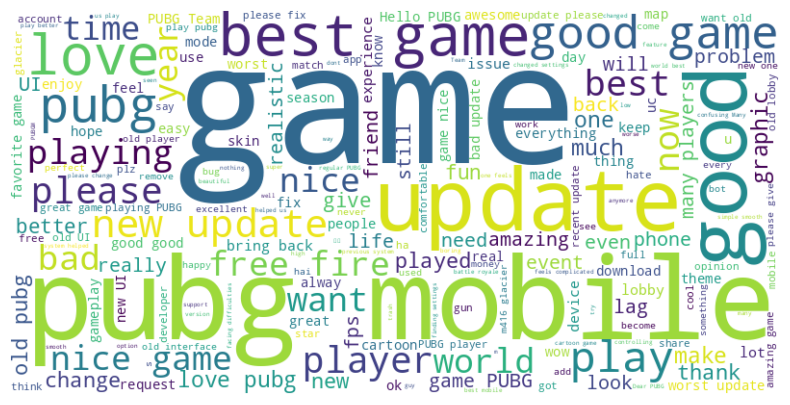

In [ ]:
# Membuat wordcloud untuk sentimen positif
text_positive = " ".join(clean_df[clean_df['label_roberta'] == 'positive']['text_akhir'].astype(str))
wordcloud = WordCloud(width = 800, height = 400, background_color = 'white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis('off')

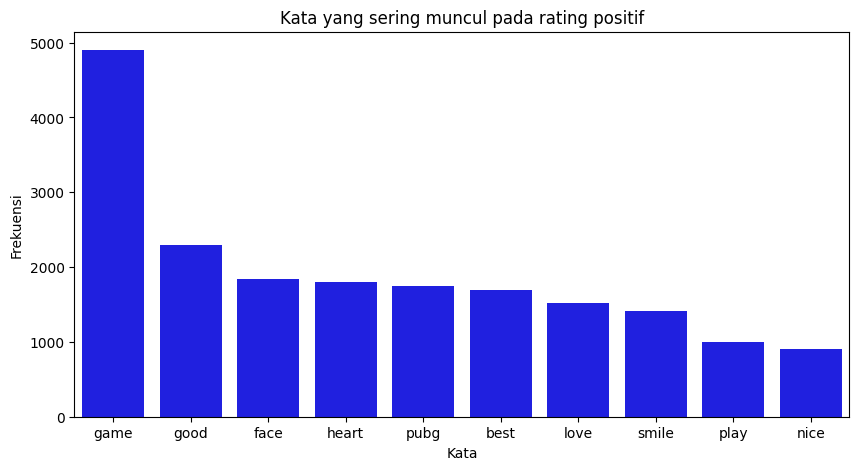

In [ ]:
positive_text = pd.Series((" ".join(clean_df[clean_df["label_roberta"] == "positive"]['text_akhir'])).split()).value_counts()[:10]
bar_plot(positive_text, 'Kata yang sering muncul pada rating positif', 'blue')

## 2. Sentimen Netral

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

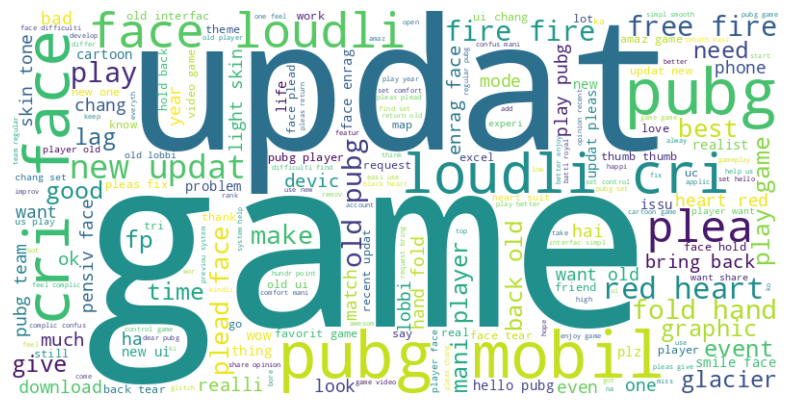

In [ ]:
# Membuat wordcloud untuk sentimen netral
text_neutral = " ".join(clean_df[clean_df["label_roberta"]=="neutral"]["text_akhir"].astype(str))
wordcloud = WordCloud(width = 800, height = 400, background_color = 'white').generate(text_neutral)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation = "bilinear")
plt.axis("off")

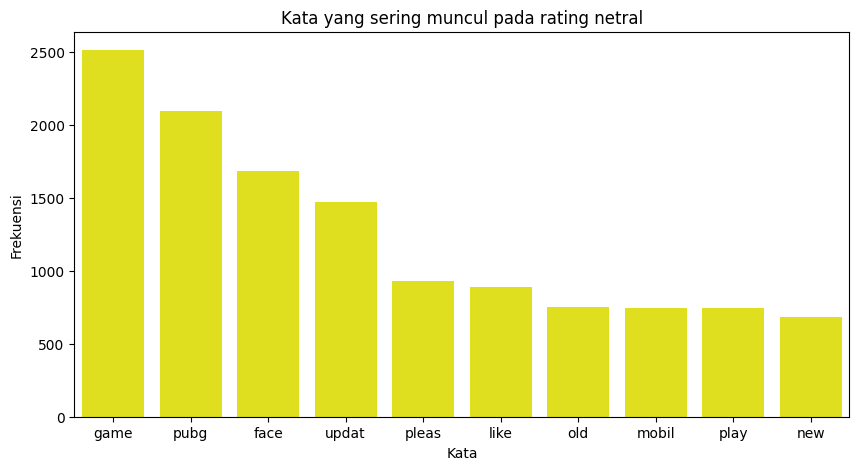

In [ ]:
# Melihat kata kata yang sering muncul pada sentimen neutral
count_words_neutral = pd.Series(text_neutral.split()).value_counts()[:10]
bar_plot(count_words_neutral, 'Kata yang sering muncul pada rating netral', 'yellow')

## 3. Sentimen Negatif

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

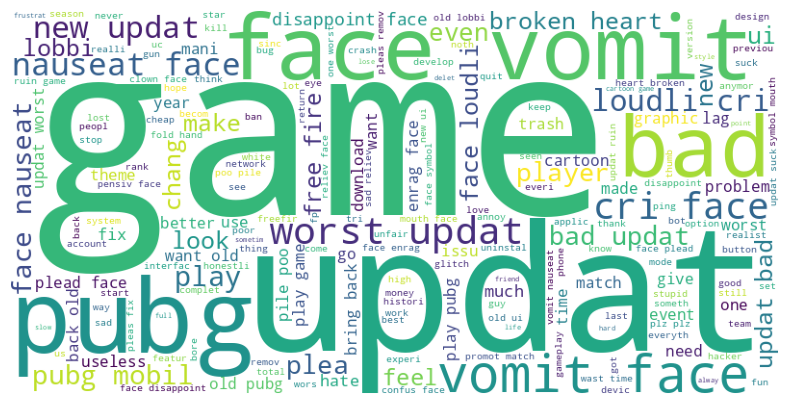

In [ ]:
# Membuat wordcloud untuk sentimen negatif
text_negative = " ".join(clean_df[clean_df["label_roberta"]=="negative"]["text_akhir"].astype(str))
wordcloud = WordCloud(width = 800, height = 400, background_color = 'white').generate(text_negative)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis("off")

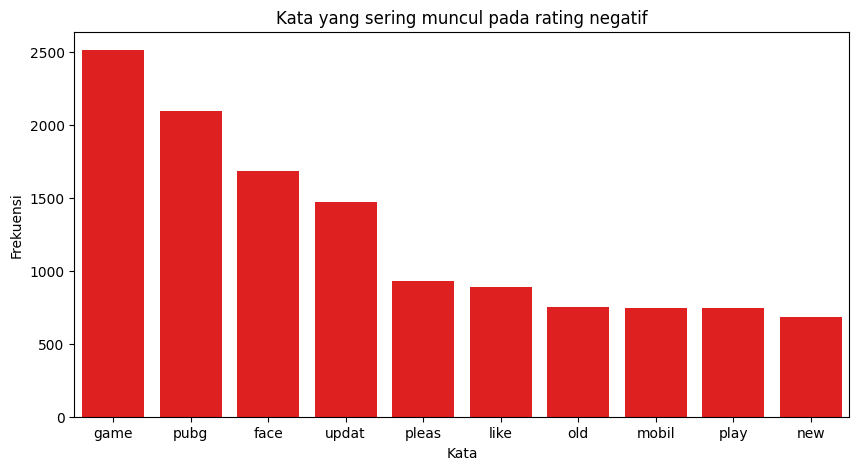

In [ ]:
# Melihat kata kata yang sering muncul pada sentimen neutral
count_words_neutral = pd.Series(text_neutral.split()).value_counts()[:10]
bar_plot(count_words_neutral, 'Kata yang sering muncul pada rating negatif', 'red')

# Tahap 7 : Melakukan Oversampling Data

In [ ]:
# Melakukan encoding terhadap label
target_map = {'positive': 2, 'neutral': 1, 'negative': 0}

# Terapkan ke dalam kolom baru yaitu label_encoded
clean_df['label_encoded'] = clean_df['label_roberta'].map(target_map)

## 7.1 Menggunakan Oversampling Manual

In [ ]:
# Copy Dataset
df_oversample = clean_df.copy()

# Melakukan pembagian X dan y
X_oversample = df_oversample['text_akhir']
y_oversample = df_oversample['label_encoded']

# Melakukan splitting dataset
X_train_oversample, X_test_oversample, y_train_oversample, y_test_oversample = train_test_split(X_oversample, y_oversample, test_size=0.2, random_state=42, stratify=y_oversample)

# Gabungkan X_train dan y_train
train_df = pd.DataFrame({'text_akhir': X_train_oversample, 'label_encoded': y_train_oversample})

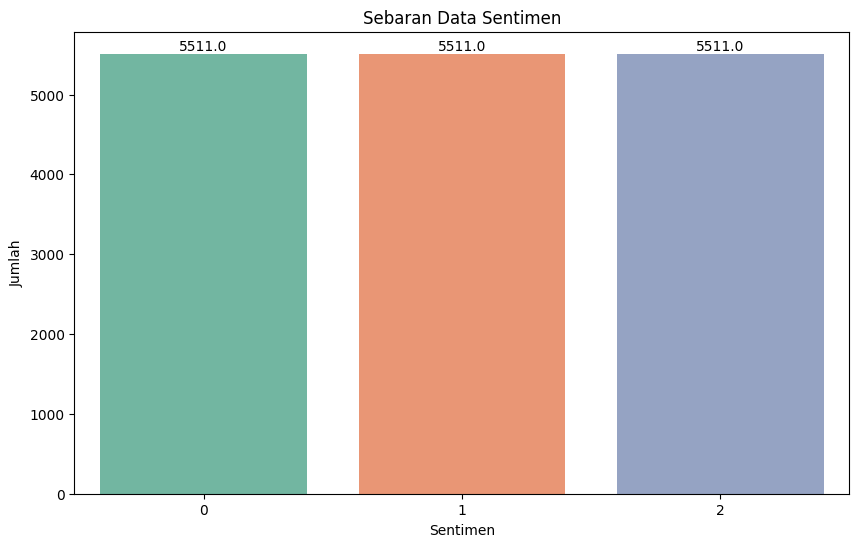

In [ ]:
# Buat target oversampling
target_count = train_df["label_encoded"].value_counts()[2]

# Data mayoritas yang akan dijadikan patokan oversampling
positive = train_df[train_df['label_encoded'] == 2]

# Oversampling pada data sentimen neutral
neutral = train_df[train_df['label_encoded'] == 1]
neutral_oversampled = neutral.sample(target_count, replace=True, random_state=42)

# Oversampling pada data sentimen negative
negative = train_df[train_df['label_encoded'] == 0]
negative_oversampled = negative.sample(target_count, replace=True, random_state=42)

# Gabungkan ketiga dataset tersebut
train_oversample = pd.concat([positive, neutral_oversampled, negative_oversampled]).sample(frac=1, random_state=42).reset_index(drop=True)

# Melihat visualisasi sebaran data
plt.figure(figsize=(10,6))
ax = sns.countplot(x='label_encoded', data=train_oversample, palette='Set2')

# Tambahkan angka di atas bar sesuai urutan plot
for p in ax.patches:
    ax.annotate(str(p.get_height()),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Sebaran Data Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')
plt.show()

### 7.1.1 Melakukan Feature Extractions dengan TF-IDF

In [ ]:
# Splitting kembali dataframe tersebut menjadi X dan y
X_train_oversample = train_oversample['text_akhir']
y_train_oversample = train_oversample['label_encoded']

In [ ]:
# Lakukan embedding dengan TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_features=10000,
    min_df=2,
    max_df=0.9
)

X_train_tfidf = tfidf.fit_transform(X_train_oversample)
X_test_tfidf = tfidf.transform(X_test_oversample)

## 7.2 Menggunakan Oversampling SMOTE

### 7.2.1 Melakukan Feature Extractions dengan FastText

In [ ]:
# Copy dataset
df_smote = clean_df.copy()

# Tentukan X dan Y
X_smote = df_smote['text_akhir']
y_smote = df_smote['label_encoded']

# Split data hasil transformasi
X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(X_smote, y_smote, test_size=0.2, random_state=42)

In [ ]:
# Lakukan embedding terlebih dahulu
# Pecah kalimat menjadi list kata
sentences = [text.split() for text in X_train_smote]

# Training model FastText
ft_model = FastText(sentences, vector_size=100, window=5, min_count=1, workers=4, sg=1)

# Membuat fungsi untuk mengubah teks menjadi vektor angka
def get_vector(text):
    words = text.split()
    # Mengambil vektor kata yang ada pada kamus ft_model
    word_vecs = [ft_model.wv[w] for w in words if w in ft_model.wv]
    if not word_vecs:
        return np.zeros(100)
    return np.mean(word_vecs, axis=0) # Rata-ratakan semua kata dalam 1 kalimat

# Terapkan embedding tersebut
X_train_smote = np.array([get_vector(text) for text in X_train_smote])
X_test_smote = np.array([get_vector(text) for text in X_test_smote])

In [ ]:
# Lakukan Ovesampling SMOTE
smote = SMOTE(sampling_strategy='auto', k_neighbors = 5, random_state=42)
X_resampled_smote, y_resampled_smote = smote.fit_resample(X_train_smote, y_train_smote)
print("SMOTE Berhasil!")

SMOTE Berhasil!


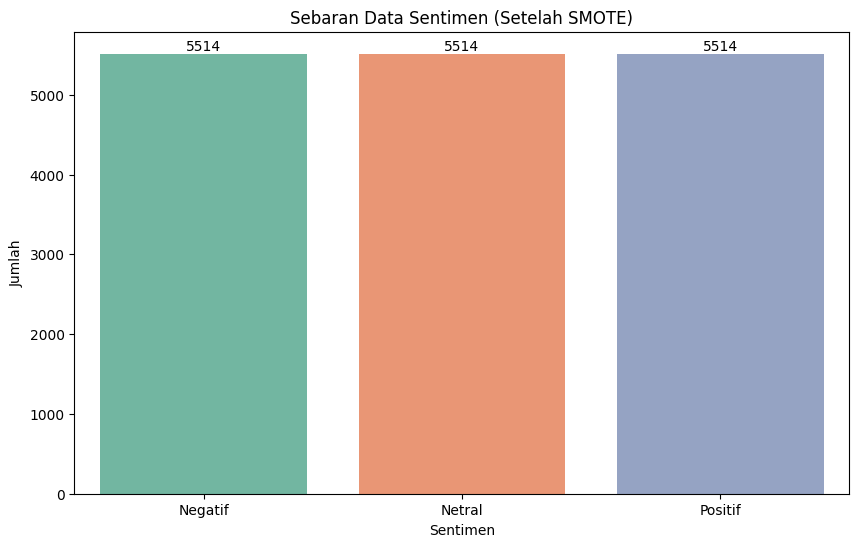

In [ ]:
# Menghitung jumlah kemunculan setiap kelas pada data hasil SMOTE
unique, counts = np.unique(y_resampled_smote, return_counts=True)
label_names = ['Negatif', 'Netral', 'Positif']

# Membuat visualisasi distribusi data sentimen dalam bentuk bar chart
plt.figure(figsize=(10,6))
ax = sns.barplot(x=label_names, y=counts, palette='Set2')

# Menambahkan anotasi berupa jumlah data di atas setiap batang (bar)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

# Menambahkan judul dan label pada sumbu grafik
plt.title('Sebaran Data Sentimen (Setelah SMOTE)')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah')

# Menampilkan grafik
plt.show()

# Tahap 8 : Modelling

## 8.1 roBERTa

In [ ]:
df_bert = clean_df.copy()

X_bert = df_bert["text_slangwords"]
y_bert = df_bert["label_encoded"]

X_train_bert, x_test_bert, y_train_bert, y_test_bert = train_test_split(X_bert, y_bert, test_size = 0.2, random_state = 42)

X_train_bert, x_val_bert, y_train_bert, y_val_bert = train_test_split(X_train_bert, y_train_bert, test_size = 0.2, random_state = 42)

In [ ]:
from transformers import RobertaTokenizer

tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

train_enc = tokenizer(list(X_train_bert), truncation=True, padding=True, max_length=128)
val_enc   = tokenizer(list(x_val_bert), truncation=True, padding=True, max_length=128)

In [ ]:
import torch

class SentimentDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels.iloc[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = SentimentDataset(train_enc, y_train_bert)
eval_dataset  = SentimentDataset(val_enc, y_val_bert)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch
import numpy as np

classes = np.unique(y_train_bert)
weights = compute_class_weight("balanced", classes=classes, y=y_train_bert)
weights = torch.tensor(weights, dtype=torch.float)

In [ ]:
from transformers import RobertaForSequenceClassification

model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(np.unique(y_train_bert))
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import Trainer
from torch.nn import CrossEntropyLoss

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs["labels"]
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fn = CrossEntropyLoss(weight=weights.to(model.device))
        loss = loss_fn(logits, labels)

        return (loss, outputs) if return_outputs else loss

from sklearn.metrics import f1_score, accuracy_score
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    output_dir="./result",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch"
)

trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.472123,0.539606,0.910417,0.910251
2,0.311380,0.470851,0.896667,0.895986
3,0.189998,0.495186,0.912083,0.912095


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3600, training_loss=0.3245005374484592, metrics={'train_runtime': 969.6114, 'train_samples_per_second': 29.703, 'train_steps_per_second': 3.713, 'total_flos': 1894416607641600.0, 'train_loss': 0.3245005374484592, 'epoch': 3.0})